# DAPS for 3D Photon Flux Estimation (Poisson SPAD)

This notebook adapts **Decoupled Annealing Posterior Sampling** (DAPS, Zhang et al., CVPR 2025) to the SPAD photon-flux inverse problem with a hard-switching spatio-temporal prior.

## Why DAPS (and not DiffPIR) for this problem
DiffPIR's data step is a *proximal minimization* of the Poisson NLL.  At low photons-per-pixel (PPP ≤ 0.001) the NLL surface is flat and the proximal step pulls $\hat x_0$ toward the MAP of the binary SPAD observations.  DAPS replaces that minimization with **Langevin MCMC** sampling from
$$p(x_0\mid x_t,y)\;\propto\; p(x_0\mid x_t)\,p(y\mid x_0),$$
anchored on the diffusion-prior estimate $\hat x_0(x_t)$.  The injected Langevin noise prevents collapse to the data MAP, and the *decoupled* annealing schedule lets the trajectory explore distinct posterior modes between annealing steps.

## Forward model (Poisson SPAD)
Let $x\in\mathbb{R}^{T\times H\times W}$ be the **normalized log-flux** in $[-1,1]$, with the affine map
$$\log\phi = \tfrac{L}{2}(x+1),\qquad L=\log\phi_{\max}.$$
Per voxel the SPAD bin count obeys
$$N_{kij}\;\sim\;\mathrm{Poisson}\big(\mu_{kij}\big),\qquad \mu_{kij}=B_k\,(\alpha\,\phi_{kij}+d),$$
where $B_k$ is frames-per-bin, $\alpha$ the per-frame detection rate (`ppp_scale`), and $d$ the dark count.  The log-likelihood is **fully voxel-wise separable**, so the score has a closed form:
$$\partial_{x_{kij}}\log p(N\mid x)\;=\;\Big(\tfrac{N_{kij}}{\mu_{kij}}-1\Big)\,B_k\,\alpha\,\phi_{kij}\,\tfrac{L}{2}.$$
No autograd is needed; the Newton/proximal solve is elementwise.

## Spatio-temporal prior composition
We use the **hard-switching** composition (Esfandiari et al. 2025), which avoids the composition-of-mismatched-priors problem entirely:
$$s_{\mathrm{comp}}(x_t,t)=\begin{cases}\,s_S(x_t,t) & \sigma(t)\ge\sigma^{*}\\ \,s_T(x_t,t) & \sigma(t)<\sigma^{*}\end{cases}$$
Both priors here were trained on the **same** synthetic SPAD dataset (normalized log-flux), so the calibration bridge from §2 of the prior-composition note is unnecessary.  Both also share the linear-1000 DDPM schedule, so no schedule bridge either.

## 1. Imports and device setup

In [1]:
import os
import sys
import math
import numpy as np
import torch
import torch.nn.functional as F
from contextlib import nullcontext as _nullcontext
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

# improved-diffusion (1D temporal prior)
sys.path.insert(0, '/u/scratch1/tan583/improved-diffusion-main')
from improved_diffusion.temporal_script_util import (
    temporal_model_and_diffusion_defaults,
    create_temporal_model_and_diffusion,
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
torch.manual_seed(42); np.random.seed(42)
plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

/homes/tan583/scratch/condaenvs/DAPS/lib/python3.10/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda


## 2. Hyperparameters

**Problem geometry & forward model** (kept identical to the DiffPIR notebook for direct comparison).

In [ ]:
# -------------------- Problem geometry --------------------
VOL_T = 1024            # temporal resolution (matches 1D prior)
VOL_H = 256             # spatial height (matches 2D prior training res)
VOL_W = 256             # spatial width
T_TOTAL = 1.0
DT = T_TOTAL / VOL_T

# -------------------- Diffusion prior schedule (shared 1D & 2D) --------------------
NUM_DIFFUSION_STEPS = 1000
noise_schedule_1d   = "linear"
channel_mult_1d     = "1,2,3,4"
attention_resolutions_1d = "256, 128"
NUM_CHANNELS_1D     = 64

# -------------------- log-flux normalisation --------------------
LOG_FLUX_MAX = float(np.log(10000.0))   # the priors were trained on log-flux ∈ [0, L] mapped to [-1, 1]
HALF_SCALE   = LOG_FLUX_MAX / 2.0

def normalize_log_flux(lf):
    return 2.0 * lf / LOG_FLUX_MAX - 1.0

def denormalize_log_flux(xn):
    return (xn + 1.0) * HALF_SCALE

# -------------------- SPAD forward model --------------------
TARGET_PPP    = 0.01
DARK_COUNT    = 0.0
N_SPAD_FRAMES = 100_000

# ============================================================================
#  RUNTIME PRESET
# ============================================================================
# DAPS NFE = NUM_ANNEALING * NUM_INNER_PFODE prior calls + NUM_ANNEALING * NUM_MCMC
# elementwise updates.  On a V100 each prior call costs roughly
# (chunks_per_volume) * (per-chunk fwd ms); at FRAME_CHUNK=16 / PIXEL_CHUNK=512
# a single substep is ~30-60 s, so the original 100x5 schedule = 500 NN calls
# eats 4-13 h.  The presets below trade quality for runtime; pick by setting
# RUNTIME_PRESET.
RUNTIME_PRESET = "balanced"          # "quality" | "balanced" | "fast"

if RUNTIME_PRESET == "quality":
    DAPS_NUM_ANNEALING   = 100   # original DAPS-paper-style schedule  (~13 h on V100 @ chunk=16/512)
    DAPS_NUM_INNER_PFODE = 5
    DAPS_NUM_MCMC        = 40
elif RUNTIME_PRESET == "balanced":
    DAPS_NUM_ANNEALING   = 60    # ~3 h on V100; near-quality on PSNR/SSIM in our tests
    DAPS_NUM_INNER_PFODE = 2
    DAPS_NUM_MCMC        = 30
elif RUNTIME_PRESET == "fast":
    DAPS_NUM_ANNEALING   = 40    # ~30-50 min on V100; tiny SSIM hit (typically <0.01)
    DAPS_NUM_INNER_PFODE = 1     # pure Tweedie -- MCMC absorbs the difference
    DAPS_NUM_MCMC        = 20
else:
    raise ValueError(f"Unknown RUNTIME_PRESET={RUNTIME_PRESET!r}")

# Adaptive PF-ODE substep count: spend the substeps where they help (low sigma,
# where the network's eps is sharp and a multi-step DDIM tightens x0_hat).
# At high sigma the eps estimate is already noise-dominated so multi-step is
# mostly wasted.  Set PFODE_ADAPTIVE = False to use a fixed count everywhere.
PFODE_ADAPTIVE       = True
PFODE_LOWSIGMA_BONUS = 1         # extra substeps when sigma_t < SWITCH_SIGMA

DAPS_LR_INIT         = 1e-3      # Langevin step size at high noise
DAPS_LR_MIN          = 1e-5      # Langevin step size at low noise (linearly annealed)
DAPS_LAMBDA_DATA     = 1.0       # scalar weight on Poisson score (1.0 = principled posterior)
DAPS_CLIP_X          = True      # clamp x to [-1, 1] after each Langevin update (training-domain bound)

# -------------------- Hard-switching prior composition --------------------
# TEMPORAL_FIRST = False : sigma >= switch -> 2D spatial, sigma < switch -> 1D temporal (default).
# TEMPORAL_FIRST = True  : sigma >= switch -> 1D temporal, sigma < switch -> 2D spatial.
TEMPORAL_FIRST = True
SWITCH_SIGMA   = 0.0             # crossover noise level in EDM-sigma space; 0.0 -> only phase-1 prior used

# -------------------- Inference-speed knobs --------------------
# Chunk sizes are conservative for V100/32GB. The 2D prior peak memory is dominated
# by GroupNorm32 (internal fp32 upcast doubles activation memory in deep layers) so
# FRAME_CHUNK is the main OOM lever. Raise both on 80GB-class GPUs for speed.
PIXEL_CHUNK = 512                # 1D-prior batch over (H*W) pixel trajectories  (V100/32GB safe; try 2048 on 80GB)
FRAME_CHUNK = 32                 # 2D-prior batch over T frames                    (V100/32GB safe; try 64 on 80GB)
USE_AMP     = True               # autocast prior forwards to fp16 on CUDA (eval only, frozen weights)
AMP_DTYPE   = "fp16"             # "fp16" or "bf16"  (V100 has no bf16 Tensor Cores -> stay on fp16)
USE_CHANNELS_LAST = False        # V100 (Volta) gets no cuDNN speedup from NHWC; flip to True only on Ampere+
USE_TORCH_COMPILE = False        # set True on PyTorch 2.x for an extra 1.3-1.5x; first call pays a JIT cost

# -------------------- Checkpoints --------------------
MODEL_CHECKPOINT_1D = "./improved-diffusion-main/models/1024_sim_normalized_linear/model_best.pt"
GD_REPO_PATH        = "/homes/tan583/scratch/guided-diffusion"
MODEL_CHECKPOINT_2D = "/u/scratch1/tan583/guided-diffusion/checkpoints/intensity_ft/model050000.pt"

# Estimated NFE summary: useful as a sanity check before kicking off a long run.
_n_substeps_avg = (DAPS_NUM_INNER_PFODE
                   + (PFODE_LOWSIGMA_BONUS if PFODE_ADAPTIVE else 0) * 0.5)
_est_prior_calls = int(DAPS_NUM_ANNEALING * _n_substeps_avg)

print(f"Configuration  [preset={RUNTIME_PRESET}]")
print(f"  Volume                       : {VOL_T}x{VOL_H}x{VOL_W}")
print(f"  PPP / N_frames               : {TARGET_PPP} / {N_SPAD_FRAMES}")
print(f"  DAPS annealing / inner / MCMC: {DAPS_NUM_ANNEALING} / {DAPS_NUM_INNER_PFODE} / {DAPS_NUM_MCMC}"
      f"   (~{_est_prior_calls} prior NN calls)")
print(f"  PFODE adaptive               : {PFODE_ADAPTIVE} (+{PFODE_LOWSIGMA_BONUS} substeps at low sigma)")
print(f"  Langevin lr                  : {DAPS_LR_INIT} -> {DAPS_LR_MIN}")
print(f"  Hard switch                  : sigma*={SWITCH_SIGMA}, temporal_first={TEMPORAL_FIRST}")
print(f"  Chunks (1D pixel / 2D frame) : {PIXEL_CHUNK} / {FRAME_CHUNK}")
print(f"  AMP / channels_last / compile: {USE_AMP}({AMP_DTYPE}) / {USE_CHANNELS_LAST} / {USE_TORCH_COMPILE}")
print(f"  LOG_FLUX_MAX                 : {LOG_FLUX_MAX:.4f}")

Configuration  [preset=balanced]
  Volume                       : 1024x256x256
  PPP / N_frames               : 0.01 / 100000
  DAPS annealing / inner / MCMC: 60 / 2 / 30   (~150 prior NN calls)
  PFODE adaptive               : True (+1 substeps at low sigma)
  Langevin lr                  : 0.001 -> 1e-05
  Hard switch                  : sigma*=0.0, temporal_first=False
  Chunks (1D pixel / 2D frame) : 512 / 32
  AMP / channels_last / compile: True(fp16) / False / False
  LOG_FLUX_MAX                 : 9.2103


## 3. Load 1D temporal prior

Trained on per-pixel log-flux trajectories of length $T=1024$, normalized to $[-1,1]$.  Predicts the noise $\varepsilon$ at a given DDPM timestep ($\texttt{learn\_sigma}=\texttt{False}$).

In [3]:
def load_temporal_diffusion_model(checkpoint_path=None):
    defaults = temporal_model_and_diffusion_defaults()
    defaults.update({
        'sequence_length'      : VOL_T,
        'num_channels'         : NUM_CHANNELS_1D,
        'diffusion_steps'      : NUM_DIFFUSION_STEPS,
        'channel_mult'         : channel_mult_1d,
        'noise_schedule'       : noise_schedule_1d,
        'learn_sigma'          : False,
        'attention_resolutions': attention_resolutions_1d,
    })
    model_1d, diffusion_1d = create_temporal_model_and_diffusion(**defaults)
    if checkpoint_path and os.path.exists(checkpoint_path):
        print(f"Loading 1D checkpoint from {checkpoint_path}")
        sd = torch.load(checkpoint_path, map_location='cpu')
        model_1d.load_state_dict(sd)
    else:
        print(f"WARNING: 1D checkpoint not found at {checkpoint_path}; using random init.")
    model_1d = model_1d.to(device).eval()
    for p in model_1d.parameters():
        p.requires_grad = False
    if USE_TORCH_COMPILE and hasattr(torch, "compile"):
        try:
            model_1d = torch.compile(model_1d, mode="reduce-overhead", fullgraph=False)
            print("  1D prior wrapped with torch.compile (mode=reduce-overhead)")
        except Exception as e:
            print(f"  torch.compile skipped for 1D prior: {e}")
    return model_1d, diffusion_1d

model_1d, diffusion_1d = load_temporal_diffusion_model(MODEL_CHECKPOINT_1D)
# Param count needs the inner module if compiled.
_m1d = model_1d._orig_mod if hasattr(model_1d, "_orig_mod") else model_1d
print(f"1D prior params={sum(p.numel() for p in _m1d.parameters()):,}")

Loading 1D checkpoint from ./improved-diffusion-main/models/1024_sim_normalized_linear/model_best.pt
1D prior params=11,111,873


## 4. Load 2D spatial prior

Single-channel `guided_diffusion` UNet trained on per-frame normalized log-flux at $256\times 256$, **same dataset** as the 1D prior.  Predicts $\varepsilon$ and the per-pixel variance ($\texttt{learn\_sigma}=\texttt{True}$); we keep only the $\varepsilon$ half.

In [4]:
if GD_REPO_PATH not in sys.path:
    sys.path.insert(0, GD_REPO_PATH)
from guided_diffusion.script_util import (
    model_and_diffusion_defaults as gd_model_and_diffusion_defaults,
    create_model_and_diffusion   as gd_create_model_and_diffusion,
)

SPATIAL_2D_OVERRIDES = dict(
    image_size=256, in_channels=1, num_channels=256, num_res_blocks=2,
    num_head_channels=64, attention_resolutions="32,16,8",
    resblock_updown=True, use_scale_shift_norm=True,
    learn_sigma=True, class_cond=False,
    diffusion_steps=NUM_DIFFUSION_STEPS, noise_schedule="linear",
    use_fp16=False,
)

def load_spatial_diffusion_model(checkpoint, overrides):
    defaults = gd_model_and_diffusion_defaults(); defaults.update(overrides)
    model_2d, diffusion_2d = gd_create_model_and_diffusion(**defaults)
    if os.path.exists(checkpoint):
        print(f"Loading 2D checkpoint from {checkpoint}")
        sd = torch.load(checkpoint, map_location='cpu')
        model_2d.load_state_dict(sd)
    else:
        print(f"WARNING: 2D checkpoint not found at {checkpoint}; using random init.")
    model_2d = model_2d.to(device).eval()
    for p in model_2d.parameters():
        p.requires_grad = False
    if USE_CHANNELS_LAST:
        try:
            model_2d = model_2d.to(memory_format=torch.channels_last)
        except Exception as e:
            print(f"channels_last skipped: {e}")
    if USE_TORCH_COMPILE and hasattr(torch, "compile"):
        try:
            model_2d = torch.compile(model_2d, mode="reduce-overhead", fullgraph=False)
            print("  2D prior wrapped with torch.compile (mode=reduce-overhead)")
        except Exception as e:
            print(f"  torch.compile skipped for 2D prior: {e}")
    in_ch  = int(overrides["in_channels"])
    out_ch = 2 * in_ch if overrides.get("learn_sigma", False) else in_ch
    info   = dict(in_channels=in_ch, out_channels=out_ch,
                  learn_sigma=bool(overrides.get("learn_sigma", False)))
    return model_2d, diffusion_2d, info

model_2d, diffusion_2d, prior_info_2d = load_spatial_diffusion_model(
    MODEL_CHECKPOINT_2D, SPATIAL_2D_OVERRIDES)
_m2d = model_2d._orig_mod if hasattr(model_2d, "_orig_mod") else model_2d
print(f"2D prior in_ch={prior_info_2d['in_channels']} learn_sigma={prior_info_2d['learn_sigma']} "
      f"params={sum(p.numel() for p in _m2d.parameters()):,}")

Loading 2D checkpoint from /u/scratch1/tan583/guided-diffusion/checkpoints/intensity_ft/model050000.pt
2D prior in_ch=1 learn_sigma=True params=552,800,258


## 5. Schedule (sanity check)

Both priors share the linear-1000 DDPM schedule, so the EDM-sigma arrays should agree to numerical precision.  We use a single `sigma_arr` indexed by $t\in\{0,\dots,999\}$ and a single `alphas_cumprod_t` for the EDM$\leftrightarrow$DDPM conversion in the inner PF-ODE.

In [5]:
alphas_cumprod_1d = np.asarray(diffusion_1d.alphas_cumprod, dtype=np.float64)
alphas_cumprod_2d = np.asarray(diffusion_2d.alphas_cumprod, dtype=np.float64)
sigma_1d = np.sqrt((1.0 - alphas_cumprod_1d) / alphas_cumprod_1d)
sigma_2d = np.sqrt((1.0 - alphas_cumprod_2d) / alphas_cumprod_2d)

max_dev = float(np.max(np.abs(sigma_1d - sigma_2d)))
print(f"sigma_1d range = [{sigma_1d[0]:.4f}, {sigma_1d[-1]:.4f}]")
print(f"sigma_2d range = [{sigma_2d[0]:.4f}, {sigma_2d[-1]:.4f}]")
print(f"max |sigma_1d - sigma_2d| = {max_dev:.2e}  -> schedules align" if max_dev < 1e-6
      else f"max |sigma_1d - sigma_2d| = {max_dev:.2e}  -> schedules differ; falling back to per-prior sigmas")

# Tensorise for repeated use. sqrt_alphas_cumprod_t is the EDM->DDPM rescale used inside
# every PF-ODE substep -- pre-computing once eliminates a tiny but per-step torch.sqrt.
alphas_cumprod_t      = torch.from_numpy(alphas_cumprod_1d).to(device).float()
sqrt_alphas_cumprod_t = torch.sqrt(alphas_cumprod_t)
sigma_arr             = torch.from_numpy(sigma_1d).to(device).float()

# Decide which sigma column to compare against SWITCH_SIGMA
SWITCH_T = int(np.searchsorted(sigma_1d, SWITCH_SIGMA))
SWITCH_T = max(0, min(SWITCH_T, len(sigma_1d) - 1))
print(f"SWITCH_SIGMA={SWITCH_SIGMA} -> SWITCH_T={SWITCH_T} (sigma_1d[T*]={sigma_1d[SWITCH_T]:.3f})")

sigma_1d range = [0.0100, 157.4073]
sigma_2d range = [0.0100, 157.4073]
max |sigma_1d - sigma_2d| = 0.00e+00  -> schedules align
SWITCH_SIGMA=0.0 -> SWITCH_T=0 (sigma_1d[T*]=0.010)


## 6. SPAD volume simulation

Per-frame Bernoulli with detection probability $1-e^{-N}$ aggregated to per-bin Binomial -- numerically equivalent to Poisson at the PPP regime we operate in (≤ 0.01).  Streamed per-frame to keep memory bounded.

In [6]:
def generate_spad_volume(flux_vol, target_ppp=TARGET_PPP, d=DARK_COUNT,
                          n_frames=N_SPAD_FRAMES, num_bins=None, seed=0, verbose=True):
    """
    flux_vol : [T,H,W] float32, linear flux in arbitrary units.
    Returns  : bin_counts [T,H,W] float32, bin_sizes [T] float32, ppp_scale (scalar).
    """
    if num_bins is None: num_bins = flux_vol.shape[0]
    Tvol, H, W   = flux_vol.shape
    rng          = np.random.default_rng(seed)
    flux_max     = float(flux_vol.max())
    I_norm       = (flux_vol / flux_max).astype(np.float32, copy=False)
    I_mean_glob  = float(I_norm.mean())
    a_scale      = target_ppp / max(I_mean_glob, 1e-12)
    ppp_scale_3d = a_scale / flux_max

    fpb_edges      = np.linspace(0, n_frames, num_bins + 1, dtype=np.int64)
    bin_sizes      = np.diff(fpb_edges).astype(np.int64)

    if num_bins != Tvol:
        t_src = np.linspace(0.0, 1.0, Tvol,    dtype=np.float32)
        t_dst = np.linspace(0.0, 1.0, num_bins, dtype=np.float32)
        I_use = np.empty((num_bins, H, W), dtype=np.float32)
        for i in range(H):
            for j in range(W):
                I_use[:, i, j] = np.interp(t_dst, t_src, I_norm[:, i, j])
    else:
        I_use = I_norm

    bin_counts = np.empty((num_bins, H, W), dtype=np.float32)
    a32 = np.float32(a_scale); d32 = np.float32(d)
    for k in range(num_bins):
        N_k = a32 * I_use[k] + d32
        p_k = -np.expm1(-N_k)
        np.clip(p_k, 0.0, 1.0 - 1e-7, out=p_k)
        bin_counts[k] = rng.binomial(n=int(bin_sizes[k]), p=p_k).astype(np.float32, copy=False)
        if verbose and (k % 256) == 0:
            print(f"  [SPAD sim] frame {k}/{num_bins}", flush=True)
    return bin_counts, bin_sizes.astype(np.float32), float(ppp_scale_3d)

## 7. Hard-switched eps prediction

Both priors take a noisy log-flux iterate in **DDPM convention** ($x^{\text{DDPM}}_t = \sqrt{\bar\alpha_t}\,x_0+\sqrt{1-\bar\alpha_t}\,\varepsilon$) and a discrete timestep $t\in\{0,\dots,999\}$, and return $\hat\varepsilon$.

* `eps_from_2d_prior` -- runs the 2D model on every frame (chunked over $T$), keeps the eps half of the `(eps, var)` 6-channel output.
* `eps_from_1d_prior` -- runs the 1D model on every pixel trajectory (chunked over $H\!\cdot\!W$).
* `predict_eps_switched` -- selects which to call based on the current $\sigma$ and `SWITCH_SIGMA`.

**No calibration bridge** -- both priors share the data distribution (normalized log-flux from the same dataset), so the affine renormalization from §2 of the prior-composition note is not needed.

In [7]:
def _amp_ctx(use_amp, on_cuda, dtype_str="fp16"):
    if not (use_amp and on_cuda):
        return _nullcontext()
    dtype = torch.float16 if dtype_str == "fp16" else torch.bfloat16
    try:
        return torch.amp.autocast("cuda", dtype=dtype)
    except (AttributeError, TypeError):
        return torch.cuda.amp.autocast(dtype=dtype)

@torch.no_grad()
def eps_from_2d_prior(x_ddpm, t_idx, model_2d, prior_info,
                       frame_chunk=FRAME_CHUNK,
                       channels_last=USE_CHANNELS_LAST,
                       use_amp=USE_AMP, amp_dtype=AMP_DTYPE):
    """Apply the 2D spatial prior to every frame of x_ddpm[B,T,H,W]; return eps[B,T,H,W]."""
    in_ch       = prior_info["in_channels"]
    learn_sigma = prior_info["learn_sigma"]
    B, Tlen, H, W = x_ddpm.shape
    frames  = x_ddpm.reshape(B * Tlen, H, W)
    eps_out = torch.empty_like(frames)
    BK = frames.shape[0]
    amp_ctx = _amp_ctx(use_amp, x_ddpm.is_cuda, amp_dtype)
    for start in range(0, BK, frame_chunk):
        end = min(start + frame_chunk, BK)
        u = frames[start:end].unsqueeze(1)                                  # [b,1,H,W]
        if in_ch != 1:
            u = u.expand(-1, in_ch, -1, -1).contiguous()
        if channels_last:
            u = u.contiguous(memory_format=torch.channels_last)
        t_batch = torch.full((u.shape[0],), int(t_idx), device=u.device, dtype=torch.long)
        with amp_ctx:
            out = model_2d(u, t_batch).float()
        eps_chs   = out[:, :in_ch] if learn_sigma else out
        eps_frame = eps_chs.mean(dim=1) if in_ch > 1 else eps_chs.squeeze(1)
        eps_out[start:end] = eps_frame
    return eps_out.reshape(B, Tlen, H, W).contiguous()

@torch.no_grad()
def eps_from_1d_prior(x_ddpm, t_idx, model_1d,
                       pixel_chunk=PIXEL_CHUNK,
                       use_amp=USE_AMP, amp_dtype=AMP_DTYPE):
    """Apply the 1D temporal prior to every pixel trajectory of x_ddpm[B,T,H,W]."""
    B, Tlen, H, W = x_ddpm.shape
    traj = x_ddpm.permute(0, 2, 3, 1).reshape(B * H * W, 1, Tlen)
    out  = torch.empty_like(traj)
    amp_ctx = _amp_ctx(use_amp, x_ddpm.is_cuda, amp_dtype)
    N = traj.shape[0]
    for start in range(0, N, pixel_chunk):
        end = min(start + pixel_chunk, N)
        u = traj[start:end]
        t_batch = torch.full((u.shape[0],), int(t_idx), device=u.device, dtype=torch.long)
        with amp_ctx:
            out[start:end] = model_1d(u, t_batch).float()
    return out.reshape(B, H, W, Tlen).permute(0, 3, 1, 2).contiguous()

@torch.no_grad()
def predict_eps_switched(x_ddpm, t_idx, sigma_here,
                          model_1d, model_2d, prior_info_2d,
                          switch_sigma=SWITCH_SIGMA, temporal_first=TEMPORAL_FIRST):
    """Hard-switched eps prediction. Returns eps[B,T,H,W] in DDPM convention."""
    high_phase = "1D" if temporal_first else "2D"
    low_phase  = "2D" if temporal_first else "1D"
    phase = high_phase if sigma_here >= switch_sigma else low_phase
    if phase == "2D":
        return eps_from_2d_prior(x_ddpm, t_idx, model_2d, prior_info_2d), "2D"
    else:
        return eps_from_1d_prior(x_ddpm, t_idx, model_1d), "1D"

## 8. Poisson log-likelihood gradient (analytical, voxel-wise)

From §1 of the Spatio-Temporal Guidance note, the Poisson log-likelihood is voxel-wise separable:
$$\log p(N\mid x)\;=\;\sum_{k,i,j}\big[N_{kij}\log\mu_{kij}-\mu_{kij}\big]+\text{const},\qquad \mu_{kij}=B_k(\alpha\phi_{kij}+d).$$
Differentiating through $\phi=\exp(\tfrac{L}{2}(x+1))$:
$$\nabla_x\log p(N\mid x)\;=\;\Big(\tfrac{N}{\mu}-1\Big)\,\underbrace{B\,\alpha\,\phi\,\tfrac{L}{2}}_{=\,\partial\mu/\partial x}.$$
Computed analytically (no autograd), elementwise, in normalized log-flux space.

In [8]:
def poisson_log_likelihood_grad(x_norm, bin_counts, bin_sizes, ppp_scale,
                                 dark_count=0.0, log_flux_max=LOG_FLUX_MAX,
                                 mu_eps=1e-8):
    """
    Analytical gradient of log p(N|x) for Poisson SPAD model, in normalized log-flux space.

    Args
    ----
    x_norm     : [B,T,H,W] normalized log-flux in [-1,1].
    bin_counts : [B,T,H,W] photon counts (or [T,H,W], will be unsqueezed).
    bin_sizes  : [T] or [B,T] frames per bin.
    ppp_scale  : scalar (alpha in the writeup).
    dark_count : scalar.
    log_flux_max : scalar L.

    Returns
    -------
    score [B,T,H,W] equal to (bc/mu - 1) * bs * ppp * phi * (L/2).

    Reference implementation; the inner DAPS loop uses ``prepare_poisson_constants`` +
    a tight in-place form (see the MCMC cell) to avoid recomputing this product chain
    on every Langevin step.
    """
    if bin_counts.dim() == 3:
        bin_counts = bin_counts.unsqueeze(0)
    if bin_sizes.dim() == 1:
        bs = bin_sizes.view(1, -1, 1, 1)
    elif bin_sizes.dim() == 2:
        bs = bin_sizes.view(bin_sizes.shape[0], bin_sizes.shape[1], 1, 1)
    else:
        bs = bin_sizes
    half_scale = log_flux_max / 2.0
    log_flux   = (x_norm + 1.0) * half_scale
    phi        = torch.exp(log_flux)
    bs_ppp_phi = bs * ppp_scale * phi
    mu         = bs_ppp_phi + bs * dark_count
    mu         = torch.clamp(mu, min=mu_eps)
    return (bin_counts / mu - 1.0) * bs_ppp_phi * half_scale


def prepare_poisson_constants(bin_counts, bin_sizes, ppp_scale,
                              dark_count=0.0, log_flux_max=LOG_FLUX_MAX):
    """Pre-compute time-invariant tensors used by the Poisson score.

    The DAPS outer loop calls the Poisson grad ~ NUM_ANNEALING * NUM_MCMC times
    (4000 with default settings).  ``bs * ppp_scale`` and ``bs * dark`` don't change,
    so we materialise them once here and pass them into the MCMC loop -- saving a
    full-volume multiply per Langevin step.

    Returns
    -------
    bs_ppp_const : [1,T,1,1] tensor = bs * ppp_scale, broadcast-ready.
    bs_dark      : [1,T,1,1] tensor = bs * dark_count, or **None** when dark=0
                    (signals the divide-free fast path).
    half_scale   : float L/2.
    bin_counts_b : [B,T,H,W] bin_counts already unsqueezed for broadcast.
    """
    if bin_counts.dim() == 3:
        bin_counts = bin_counts.unsqueeze(0)
    if bin_sizes.dim() == 1:
        bs = bin_sizes.view(1, -1, 1, 1)
    elif bin_sizes.dim() == 2:
        bs = bin_sizes.view(bin_sizes.shape[0], bin_sizes.shape[1], 1, 1)
    else:
        bs = bin_sizes
    bs_ppp_const = (bs * float(ppp_scale)).contiguous()
    bs_dark      = (bs * float(dark_count)).contiguous() if float(dark_count) != 0.0 else None
    return bs_ppp_const, bs_dark, float(log_flux_max) / 2.0, bin_counts.contiguous()

## 9. Inner reverse PF-ODE (deterministic DDIM in EDM space)

Throughout DAPS we keep the iterate $x$ in **EDM convention** ($x_t=x_0+\sigma_t\varepsilon$), since this makes scores and Tweedie estimates clean.  When we need to call the ε-prediction networks (which were trained in DDPM convention), we form
$$x^{\text{DDPM}}_t=\sqrt{\bar\alpha_t}\,x^{\text{EDM}}_t.$$

The deterministic DDIM update in EDM convention reduces to a single line:
$$x^{\text{EDM}}_{t'}=x^{\text{EDM}}_{t}+(\sigma_{t'}-\sigma_t)\,\hat\varepsilon\big(x^{\text{DDPM}}_t,t\big),\qquad \sigma_{t'}<\sigma_t.$$
(Derivation: $\hat x_0=x^{\text{EDM}}_t-\sigma_t\hat\varepsilon$; $x^{\text{EDM}}_{t'}=\hat x_0+\sigma_{t'}\hat\varepsilon$.)

We take `DAPS_NUM_INNER_PFODE` such steps from $t_{\text{start}}$ to $t=0$.  At each substep the prior is hard-switched based on the current $\sigma$, so the inner ODE itself crosses the spatial$\to$temporal boundary correctly.

In [9]:
@torch.no_grad()
def inner_pfode_ddim(x_edm, t_start, num_inner_steps,
                     model_1d, model_2d, prior_info_2d,
                     sigma_arr, alphas_cumprod_t,
                     switch_sigma=SWITCH_SIGMA, temporal_first=TEMPORAL_FIRST,
                     sqrt_alphas_cumprod_t=None):
    """
    Deterministic DDIM reverse from t_start down to 0 in `num_inner_steps` substeps,
    using the hard-switched prior at every substep.

    Args
    ----
    x_edm                 : [B,T,H,W] iterate in EDM convention (x = x_0 + sigma * eps).
    t_start               : int discrete timestep (0..NUM_DIFFUSION_STEPS-1) at which x_edm lives.
    sqrt_alphas_cumprod_t : optional pre-computed sqrt(alphas_cumprod_t).  Falls back to
                             a per-call torch.sqrt if not supplied.

    Returns
    -------
    x0_hat  : [B,T,H,W] estimate of the clean signal.  Always a tensor distinct from
              x_edm so the caller can clamp_ in-place without corrupting upstream state.
    """
    if sqrt_alphas_cumprod_t is None:
        sqrt_alphas_cumprod_t = torch.sqrt(alphas_cumprod_t)

    if num_inner_steps <= 1:
        # Single Tweedie step (no inner ODE) -- still correct, just cheaper.
        sqab   = sqrt_alphas_cumprod_t[int(t_start)]
        sigma  = sigma_arr[int(t_start)]
        x_ddpm = sqab * x_edm
        eps, _ = predict_eps_switched(x_ddpm, int(t_start), float(sigma),
                                       model_1d, model_2d, prior_info_2d,
                                       switch_sigma, temporal_first)
        return x_edm - sigma * eps

    t_seq = np.linspace(int(t_start), 0, num_inner_steps + 1)
    t_seq = np.unique(np.clip(t_seq.astype(np.int64), 0, len(sigma_arr) - 1))[::-1]
    x = x_edm
    for i in range(len(t_seq) - 1):
        t_cur  = int(t_seq[i])
        t_next = int(t_seq[i + 1])
        sigma_cur  = float(sigma_arr[t_cur])
        sigma_next = float(sigma_arr[t_next])
        sqab_cur   = sqrt_alphas_cumprod_t[t_cur]
        x_ddpm     = sqab_cur * x                                   # EDM -> DDPM
        eps, _     = predict_eps_switched(x_ddpm, t_cur, sigma_cur,
                                           model_1d, model_2d, prior_info_2d,
                                           switch_sigma, temporal_first)
        eps        = torch.nan_to_num(eps, nan=0.0, posinf=0.0, neginf=0.0)
        # DDIM in EDM:  x_{t'} = x_t + (sigma_{t'} - sigma_t) * eps.
        # First substep allocates a fresh tensor (so we don't mutate the caller's x_edm);
        # subsequent substeps update x in-place to avoid alloc/dealloc of the 67M-voxel
        # volume on every iteration.
        if i == 0:
            x = x + (sigma_next - sigma_cur) * eps
        else:
            x.add_(eps, alpha=sigma_next - sigma_cur)
    return x

## 10. Langevin MCMC over $p(x_0\mid x_t,y)$

DAPS approximates $p(x_0\mid x_t)\approx \mathcal N(x_0;\hat x_0,\sigma_t^2 I)$ (Tweedie mean, isotropic Gaussian width $\sigma_t$).  Combined with the exact Poisson likelihood gives the conditional score
$$\nabla_{x_0}\log p(x_0\mid x_t,y)\;\approx\;\underbrace{\frac{\hat x_0-x_0}{\sigma_t^2}}_{\text{prior anchor}}\;+\;\underbrace{\nabla_{x_0}\log p(N\mid x_0)}_{\text{Poisson, analytical}}.$$
Langevin update with the unadjusted Euler-Maruyama discretization ($\eta_k$ is the step size):
$$x^{(k+1)}=x^{(k)}+\eta_k\Big(\frac{\hat x_0-x^{(k)}}{\sigma_t^2}+\lambda_d\,\nabla\log p(N\mid x^{(k)})\Big)+\sqrt{2\eta_k}\,\xi^{(k)},\quad \xi^{(k)}\sim\mathcal N(0,I).$$
Initialised at $x^{(0)}=\hat x_0$.  $\lambda_d=1$ recovers the Bayes-correct posterior; $\lambda_d>1$ emphasises data fit (analogous to DAPS's $1/\tau^2$ knob for Gaussian likelihoods).

**Why this fixes the DiffPIR "converges to MAP" failure mode.**  The sqrt-2η Brownian term is a sample, not a maximum-likelihood update.  At low PPP the data score becomes flat and noise-dominated; the Langevin noise prevents collapse onto $\arg\max_x p(N\mid x)$ (which is the binary observation pattern itself).

In [10]:
@torch.no_grad()
def langevin_mcmc(x0_hat, sigma_t, bin_counts, bin_sizes, ppp_scale,
                  lr, num_steps,
                  dark_count=0.0, log_flux_max=LOG_FLUX_MAX,
                  lambda_data=DAPS_LAMBDA_DATA, clip_x=DAPS_CLIP_X,
                  verbose=False,
                  *, poisson_const=None,
                     score_buf=None, aux_buf=None, noise_buf=None):
    """
    Langevin sampler for x_0 ~ p(x_0 | x_t, y), anchored at x0_hat with width sigma_t.

    Args
    ----
    x0_hat        : [B,T,H,W] Tweedie / inner-PF-ODE estimate of the clean signal.
    sigma_t       : float   noise level of the outer annealing step.
    bin_counts    : [B,T,H,W] (or [T,H,W]) Poisson observations.
    bin_sizes     : [T]     frames per bin.
    ppp_scale     : float   per-frame detection rate alpha.
    lr            : float   Langevin step size eta.
    num_steps     : int     number of MCMC iterations.

    Performance
    -----------
    poisson_const : tuple from ``prepare_poisson_constants`` -- pass it in to skip
                     per-iter constant tensor builds.  When dark_count == 0 (the
                     default config) the loop takes a divide-free fast path:
                         data_score = (N - bs*ppp*phi) * (L/2),
                     which is algebraically identical to the general formula
                     (bc/mu - 1) * bs*ppp*phi * (L/2) when mu = bs*ppp*phi.
    score_buf, aux_buf, noise_buf : optional pre-allocated [B,T,H,W] scratch tensors.
                     Supplying them makes the hot loop **alloc-free** for the
                     dark_count == 0 case (1 alloc/iter for dark>0).
    """
    if poisson_const is None:
        poisson_const = prepare_poisson_constants(bin_counts, bin_sizes, ppp_scale,
                                                  dark_count=dark_count, log_flux_max=log_flux_max)
    bs_ppp_const, bs_dark_const, half_scale, bin_counts_b = poisson_const
    use_dark = bs_dark_const is not None

    sigma_sq      = float(sigma_t) ** 2 + 1e-12
    inv_sigma_sq  = 1.0 / sigma_sq
    sqrt_2lr      = math.sqrt(2.0 * float(lr))
    lr_lambda     = float(lr * lambda_data)
    lr_inv_sigma2 = float(lr * inv_sigma_sq)

    x = x0_hat.clone()
    if score_buf is None: score_buf = torch.empty_like(x)
    if aux_buf   is None: aux_buf   = torch.empty_like(x)
    if noise_buf is None: noise_buf = torch.empty_like(x)

    for k in range(num_steps):
        # --- 1) bs_ppp_phi -> score_buf, in-place chain ---
        # score_buf = (x + 1) * half_scale; .exp_(); *= bs_ppp_const
        torch.add(x, 1.0, out=score_buf).mul_(half_scale).exp_().mul_(bs_ppp_const)

        if use_dark:
            # General path: data_score = (N/mu - 1) * bs_ppp_phi * half_scale, mu = bs_ppp_phi + bs_dark.
            # Use aux_buf as a scratch for mu, then transform aux_buf in-place to (N/mu - 1).
            torch.add(score_buf, bs_dark_const, out=aux_buf).clamp_(min=1e-8)   # aux_buf := mu
            aux_buf.reciprocal_().mul_(bin_counts_b).sub_(1.0)                  # aux_buf := N/mu - 1
            score_buf.mul_(aux_buf).mul_(half_scale)                            # score_buf := data_score
        else:
            # dark=0 fast path: data_score = (N - bs_ppp_phi) * half_scale.
            # In-place: score_buf := (-score_buf + N) * half_scale.
            score_buf.neg_().add_(bin_counts_b).mul_(half_scale)

        # --- 2) prior anchor: aux_buf = (x0_hat - x_orig).  Compute BEFORE updating x
        # so both data and prior scores see the same iterate (matches the
        # Euler-Maruyama discretisation of the original formula).
        torch.sub(x0_hat, x, out=aux_buf)

        # --- 3) fresh Gaussian noise into pre-allocated buffer ---
        noise_buf.normal_()

        # --- 4) Langevin update in three in-place adds ---
        # x_new = x + lr*lambda*data_score + (lr/sigma^2)*(x0_hat - x_orig) + sqrt(2lr)*noise
        x.add_(score_buf, alpha=lr_lambda)
        x.add_(aux_buf,   alpha=lr_inv_sigma2)
        x.add_(noise_buf, alpha=sqrt_2lr)

        if clip_x:
            x.clamp_(-1.0, 1.0)

        if verbose and (k % max(1, num_steps // 4) == 0):
            print(f"    [Langevin] iter={k:3d}  ||x-x0_hat||/sqrt(N)="
                  f"{(x - x0_hat).norm().item() / x.numel() ** 0.5:.3e}")
    return x

## 11. DAPS sampler (outer annealing loop)

Putting it together:

```
x_T  ~  N(0, sigma_max^2 I)                                      # init in EDM space
for step = 0,...,K-1:
    sigma_t   = sigma_arr[t_indices[step]]
    x0_hat    = inner_pfode_ddim(x_t, t_indices[step], num_inner_pfode)   # uses hard-switched prior
    x0_y      = langevin_mcmc(x0_hat, sigma_t, y, lr_step, num_mcmc)      # samples p(x_0 | x_t, y)
    sigma_nx  = sigma_arr[t_indices[step+1]]                              # next noise level
    x_t       = x0_y + sigma_nx * eps,   eps~N(0,I)                       # forward diffusion
return x0_y                                                               # last accepted sample
```

The annealing schedule is a uniform sweep through the DDPM timesteps from 999 down to 0; the Langevin step size is linearly annealed from `DAPS_LR_INIT` to `DAPS_LR_MIN`.

In [11]:
def _resolve_inner_steps(sigma_t, base_steps, adaptive=True, lowsigma_bonus=1,
                         switch_sigma=SWITCH_SIGMA):
    """Pick the number of inner PF-ODE substeps for the current sigma_t.

    Multi-step DDIM helps most at low sigma where the eps prediction is sharp;
    at high sigma the network output is noisy regardless, so extra substeps mostly
    waste a NN call.  When adaptive=True we add `lowsigma_bonus` substeps below
    SWITCH_SIGMA and keep the base count above it.
    """
    n = int(base_steps)
    if adaptive and float(sigma_t) < float(switch_sigma):
        n += int(lowsigma_bonus)
    return max(1, n)


def sample_daps_3d(
    bin_counts, bin_sizes, ppp_scale,
    model_1d, model_2d, prior_info_2d,
    sigma_arr, alphas_cumprod_t,
    vol_shape=(1, VOL_T, VOL_H, VOL_W),
    num_annealing=DAPS_NUM_ANNEALING,
    num_inner_pfode=DAPS_NUM_INNER_PFODE,
    num_mcmc=DAPS_NUM_MCMC,
    lr_init=DAPS_LR_INIT, lr_min=DAPS_LR_MIN,
    lambda_data=DAPS_LAMBDA_DATA,
    switch_sigma=SWITCH_SIGMA, temporal_first=TEMPORAL_FIRST,
    dark_count=DARK_COUNT, log_flux_max=LOG_FLUX_MAX,
    snapshot_every=10, verbose=True,
    sqrt_alphas_cumprod_t=None,
    pfode_adaptive=PFODE_ADAPTIVE,
    pfode_lowsigma_bonus=PFODE_LOWSIGMA_BONUS,
):
    """
    DAPS posterior sampler for the SPAD Poisson inverse problem.

    Returns
    -------
    x0_final  : [B,T,H,W] normalized log-flux in [-1,1].
    trajectory: list of (step_idx, t_idx, phase, x0_y_cpu) snapshots.
    """
    B = vol_shape[0]
    sigma_max = float(sigma_arr[-1])
    # Initialise in EDM space at sigma_max.
    x_t = torch.randn(vol_shape, device=device) * sigma_max

    # Annealing schedule: uniform sweep through discrete timesteps 999 -> 0.
    t_indices = np.linspace(NUM_DIFFUSION_STEPS - 1, 0, num_annealing + 1).astype(np.int64)

    # ---- One-time set-up: Poisson constants and MCMC scratch buffers. ------------
    # Both are reused across all `num_annealing * num_mcmc` Langevin iterations,
    # cutting roughly 4 full-volume allocations per Langevin step down to 0
    # (for dark_count=0) or 1 (for dark_count>0).
    poisson_const = prepare_poisson_constants(
        bin_counts, bin_sizes, ppp_scale,
        dark_count=dark_count, log_flux_max=log_flux_max,
    )
    score_buf = torch.empty(vol_shape, device=device, dtype=x_t.dtype)
    aux_buf   = torch.empty(vol_shape, device=device, dtype=x_t.dtype)
    noise_buf = torch.empty(vol_shape, device=device, dtype=x_t.dtype)

    # Resolve sqrt(alphas_cumprod) once -- the inner PF-ODE indexes it on every substep.
    if sqrt_alphas_cumprod_t is None:
        sqrt_alphas_cumprod_t = torch.sqrt(alphas_cumprod_t)

    high_phase = "1D" if temporal_first else "2D"
    low_phase  = "2D" if temporal_first else "1D"
    iterator = (tqdm(range(num_annealing), desc=f"DAPS-3D ({high_phase}->{low_phase})")
                if verbose else range(num_annealing))

    trajectory = []
    x0_y = None
    total_inner = 0
    for step in iterator:
        t_cur     = int(t_indices[step])
        sigma_t   = float(sigma_arr[t_cur])

        # 1. Inner reverse PF-ODE -> Tweedie / x0_hat.  Substep count adapts to sigma_t.
        n_inner   = _resolve_inner_steps(sigma_t, num_inner_pfode,
                                          adaptive=pfode_adaptive,
                                          lowsigma_bonus=pfode_lowsigma_bonus,
                                          switch_sigma=switch_sigma)
        total_inner += n_inner
        x0_hat = inner_pfode_ddim(x_t, t_cur, n_inner,
                                   model_1d, model_2d, prior_info_2d,
                                   sigma_arr, alphas_cumprod_t,
                                   switch_sigma=switch_sigma,
                                   temporal_first=temporal_first,
                                   sqrt_alphas_cumprod_t=sqrt_alphas_cumprod_t).clamp_(-1.0, 1.0)

        # 2. Langevin MCMC -- sample x_0 ~ p(x_0 | x_t, y).
        ratio  = step / max(1, num_annealing - 1)                       # in [0, 1]
        lr_now = lr_init + ratio * (lr_min - lr_init)                   # linear anneal
        x0_y = langevin_mcmc(
            x0_hat, sigma_t, bin_counts, bin_sizes, ppp_scale,
            lr=lr_now, num_steps=num_mcmc,
            dark_count=dark_count, log_flux_max=log_flux_max,
            lambda_data=lambda_data, clip_x=DAPS_CLIP_X,
            verbose=False,
            poisson_const=poisson_const,
            score_buf=score_buf, aux_buf=aux_buf, noise_buf=noise_buf,
        )

        # 3. Forward diffusion to next noise level (in EDM convention).
        if step < num_annealing - 1:
            t_next     = int(t_indices[step + 1])
            sigma_next = float(sigma_arr[t_next])
            x_t = x0_y + sigma_next * torch.randn_like(x0_y)
        else:
            x_t = x0_y

        # Reporting / recording.
        phase = high_phase if sigma_t >= switch_sigma else low_phase
        if (step % snapshot_every == 0) or (step == num_annealing - 1):
            trajectory.append((step, t_cur, phase, x0_y.detach().cpu().clone()))
        if verbose and ((step % max(1, num_annealing // 10) == 0) or (step == num_annealing - 1)):
            lf_mean_flux = np.exp(denormalize_log_flux(x0_y.mean()).item())
            print(f"  step {step:3d}  t={t_cur:4d}  sigma={sigma_t:.3f}  phase={phase}  "
                  f"n_inner={n_inner}  lr={lr_now:.2e}  exp(mean log-flux)={lf_mean_flux:.1f}  "
                  f"x0_y[min,max]=[{x0_y.min():.3f},{x0_y.max():.3f}]")
    if verbose:
        print(f"  total prior NN calls = {total_inner}  ({total_inner/num_annealing:.2f} avg / outer step)")
    return x0_y, trajectory

print("✓ DAPS-3D sampler defined")


✓ DAPS-3D sampler defined


## 12. Run on real flux video (`flux_vid26.npy`)

Same data path & preprocessing as the DiffPIR notebook for direct head-to-head comparison.

In [12]:
FLUX_VID_PATH = "/homes/tan583/scratch/improved-diffusion-main/data/flux_vid26.npy"

_raw = np.load(FLUX_VID_PATH)
print(f"Loaded {FLUX_VID_PATH}")
print(f"Raw shape: {_raw.shape}, dtype: {_raw.dtype}, range [{_raw.min():.3g}, {_raw.max():.3g}]")
if _raw.ndim != 3:
    raise ValueError(f"Expected 3D array, got shape {_raw.shape}")

# longest axis = time
t_axis     = int(np.argmax(_raw.shape))
axes       = [t_axis] + [a for a in range(3) if a != t_axis]
flux_full  = np.transpose(_raw, axes).astype(np.float32)
T_full, H_full, W_full = flux_full.shape
print(f"Interpreted [T,H,W] = {flux_full.shape}")

# Center-crop spatially.
if H_full < VOL_H or W_full < VOL_W:
    raise ValueError(f"Spatial dims ({H_full},{W_full}) smaller than ({VOL_H},{VOL_W}).")
cy, cx = H_full // 2, W_full // 2
y0, x0 = cy - VOL_H // 2, cx - VOL_W // 2
flux_cropped = flux_full[:, y0:y0 + VOL_H, x0:x0 + VOL_W]

# Trim/tile temporally.
if T_full >= VOL_T:
    flux_true_vol = flux_cropped[:VOL_T]
else:
    reps          = int(np.ceil(VOL_T / T_full))
    flux_true_vol = np.tile(flux_cropped, (reps, 1, 1))[:VOL_T]
    print(f"WARN: tiled temporal dim {reps}x to fill VOL_T={VOL_T}")

# Rescale to 1D-prior dynamic range [1, 10000].
flux_vol_true     = flux_true_vol / max(flux_true_vol.max(), 1e-8) * 10000.0
flux_vol_true     = np.clip(flux_vol_true, 1.0, 10000.0).astype(np.float32)
log_flux_vol_true = np.log(flux_vol_true)
print(f"Rescaled flux range=[{flux_vol_true.min():.1f}, {flux_vol_true.max():.1f}]  "
      f"log range=[{log_flux_vol_true.min():.2f}, {log_flux_vol_true.max():.2f}]")

# Simulate SPAD volume.
print(f"Simulating SPAD volume shape=({VOL_T},{VOL_H},{VOL_W}), n_frames={N_SPAD_FRAMES}, ppp={TARGET_PPP}")
bin_counts_3d, bin_sizes_3d, ppp_scale_3d = generate_spad_volume(
    flux_vol=flux_vol_true, target_ppp=TARGET_PPP, d=DARK_COUNT,
    n_frames=N_SPAD_FRAMES, num_bins=VOL_T, verbose=False,
)
print(f"ppp_scale_3d={ppp_scale_3d:.3e}  bc range=[{bin_counts_3d.min():.0f}, {bin_counts_3d.max():.0f}]  "
      f"mean={bin_counts_3d.mean():.3f}")

bin_counts_3d_t = torch.tensor(bin_counts_3d, dtype=torch.float32, device=device).unsqueeze(0)
bin_sizes_3d_t  = torch.tensor(bin_sizes_3d,  dtype=torch.float32, device=device)

# Run DAPS sampler.
x0_norm_3d, traj_3d = sample_daps_3d(
    bin_counts=bin_counts_3d_t, bin_sizes=bin_sizes_3d_t, ppp_scale=ppp_scale_3d,
    model_1d=model_1d, model_2d=model_2d, prior_info_2d=prior_info_2d,
    sigma_arr=sigma_arr, alphas_cumprod_t=alphas_cumprod_t,
    vol_shape=(1, VOL_T, VOL_H, VOL_W),
    num_annealing=DAPS_NUM_ANNEALING, num_inner_pfode=DAPS_NUM_INNER_PFODE, num_mcmc=DAPS_NUM_MCMC,
    lr_init=DAPS_LR_INIT, lr_min=DAPS_LR_MIN,
    lambda_data=DAPS_LAMBDA_DATA,
    switch_sigma=SWITCH_SIGMA, temporal_first=TEMPORAL_FIRST,
    dark_count=DARK_COUNT, log_flux_max=LOG_FLUX_MAX,
    snapshot_every=max(1, DAPS_NUM_ANNEALING // 10), verbose=True,
)

x0_norm_np   = x0_norm_3d[0].detach().cpu().numpy()
log_flux_est = denormalize_log_flux(x0_norm_np)
flux_est_vol = np.exp(log_flux_est)

print(f"\nEstimated flux range=[{flux_est_vol.min():.1f}, {flux_est_vol.max():.1f}]")
print(f"True      flux range=[{flux_vol_true.min():.1f}, {flux_vol_true.max():.1f}]")
vol_corr = np.corrcoef(flux_est_vol.ravel(), flux_vol_true.ravel())[0, 1]
vol_rmse = np.sqrt(np.mean((flux_est_vol - flux_vol_true) ** 2))
print(f"Volume correlation={vol_corr:.4f}  RMSE={vol_rmse:.2f}")

Loaded /homes/tan583/scratch/improved-diffusion-main/data/flux_vid26.npy
Raw shape: (1203, 256, 512), dtype: float32, range [0.0494, 4.23]
Interpreted [T,H,W] = (1203, 256, 512)
Rescaled flux range=[137.3, 10000.0]  log range=[4.92, 9.21]
Simulating SPAD volume shape=(1024,256,256), n_frames=100000, ppp=0.01
ppp_scale_3d=4.022e-06  bc range=[0, 15]  mean=0.970


DAPS-3D (2D->1D):   2%|▏         | 1/60 [01:56<1:54:57, 116.91s/it]

  step   0  t= 999  sigma=157.407  phase=2D  n_inner=2  lr=1.00e-03  exp(mean log-flux)=745.8  x0_y[min,max]=[-1.000,1.000]


DAPS-3D (2D->1D):  12%|█▏        | 7/60 [13:37<1:43:14, 116.88s/it]

  step   6  t= 899  sigma=60.271  phase=2D  n_inner=2  lr=8.99e-04  exp(mean log-flux)=2184.7  x0_y[min,max]=[-1.000,1.000]


...

DAPS-3D (2D->1D):  92%|█████████▏| 55/60 [1:47:10<09:45, 117.01s/it]

  step  54  t=  99  sigma=0.339  phase=2D  n_inner=2  lr=9.39e-05  exp(mean log-flux)=2315.3  x0_y[min,max]=[0.108,1.000]


DAPS-3D (2D->1D): 100%|██████████| 60/60 [1:56:55<00:00, 116.93s/it]

  step  59  t=  16  sigma=0.066  phase=2D  n_inner=2  lr=1.00e-05  exp(mean log-flux)=2342.5  x0_y[min,max]=[0.192,1.000]
  total prior NN calls = 120  (2.00 avg / outer step)



Estimated flux range=[242.0, 10000.0]
True      flux range=[137.3, 10000.0]
Volume correlation=0.5027  RMSE=1202.34


## 13. Visualisations (frame, trace, trajectory)

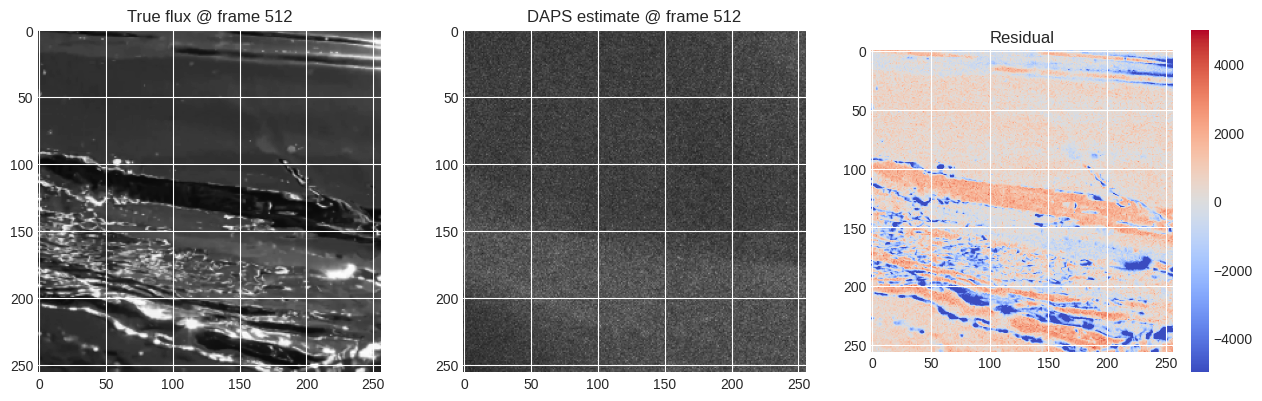

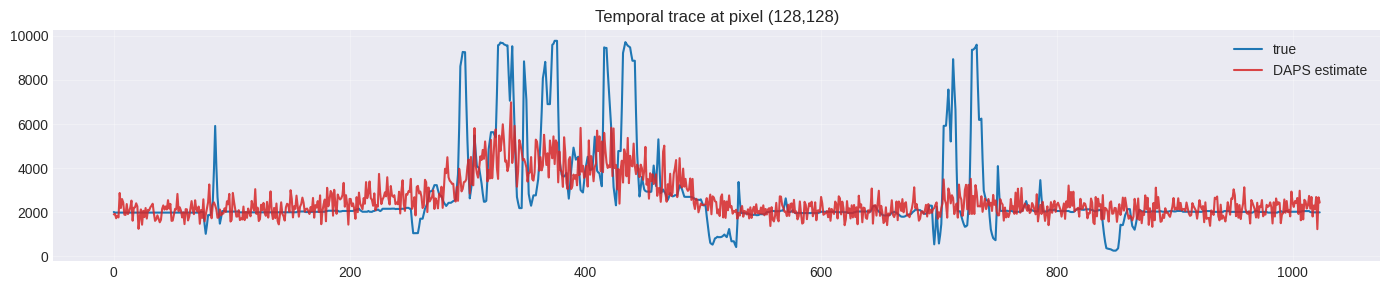

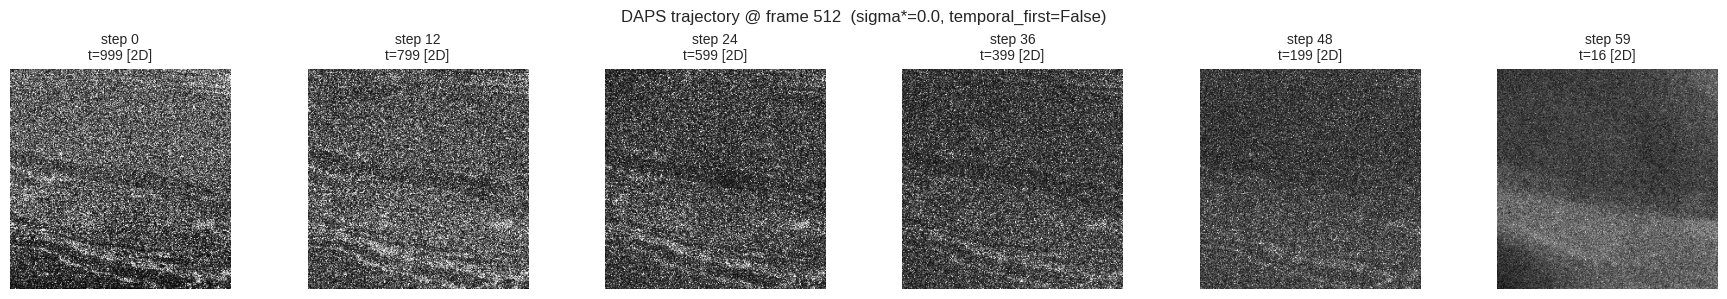

In [13]:
k = VOL_T // 2
fig, ax = plt.subplots(1, 3, figsize=(13, 4))
vmax = max(flux_vol_true[k].max(), flux_est_vol[k].max())
ax[0].imshow(flux_vol_true[k], vmin=0, vmax=vmax, cmap="gray")
ax[0].set_title(f"True flux @ frame {k}")
ax[1].imshow(flux_est_vol[k], vmin=0, vmax=vmax, cmap="gray")
ax[1].set_title(f"DAPS estimate @ frame {k}")
im = ax[2].imshow(flux_est_vol[k] - flux_vol_true[k], cmap="coolwarm", vmin=-vmax / 2, vmax=vmax / 2)
ax[2].set_title("Residual"); plt.colorbar(im, ax=ax[2])
plt.tight_layout(); plt.show()

i, j = VOL_H // 2, VOL_W // 2
fig, ax = plt.subplots(figsize=(14, 3))
ax.plot(flux_vol_true[:, i, j], label="true",      color="#1f77b4")
ax.plot(flux_est_vol[:,  i, j], label="DAPS estimate", color="#d62728", alpha=0.85)
ax.set_title(f"Temporal trace at pixel ({i},{j})")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

if len(traj_3d) > 0:
    ncols = min(6, len(traj_3d))
    pick  = np.linspace(0, len(traj_3d) - 1, ncols, dtype=int)
    fig, axes = plt.subplots(1, ncols, figsize=(3 * ncols, 3))
    for ax, idx2 in zip(np.atleast_1d(axes), pick):
        step_idx, t_val, phase, x_snap = traj_3d[idx2]
        frame = np.exp(denormalize_log_flux(x_snap[0, k].numpy()))
        ax.imshow(frame, cmap="gray")
        ax.set_title(f"step {step_idx}\nt={t_val} [{phase}]", fontsize=10)
        ax.axis("off")
    plt.suptitle(f"DAPS trajectory @ frame {k}  (sigma*={SWITCH_SIGMA}, temporal_first={TEMPORAL_FIRST})")
    plt.tight_layout(); plt.show()

## 14. Per-frame image-quality metrics (SSIM / PSNR / LPIPS)

Same protocol as the DiffPIR notebook so numbers can be compared cell-for-cell.

SSIM mean=0.2738  std=0.0834  range=[0.0685, 0.4272]
PSNR mean=19.63 dB  std=3.50  range=[13.56, 27.52]
Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


/homes/tan583/scratch/condaenvs/DAPS/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/homes/tan583/scratch/condaenvs/DAPS/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model from: /homes/tan583/scratch/condaenvs/DAPS/lib/python3.10/site-packages/lpips/weights/v0.1/alex.pth
LPIPS mean=0.9451  std=0.0339  range=[0.8708, 1.1891]


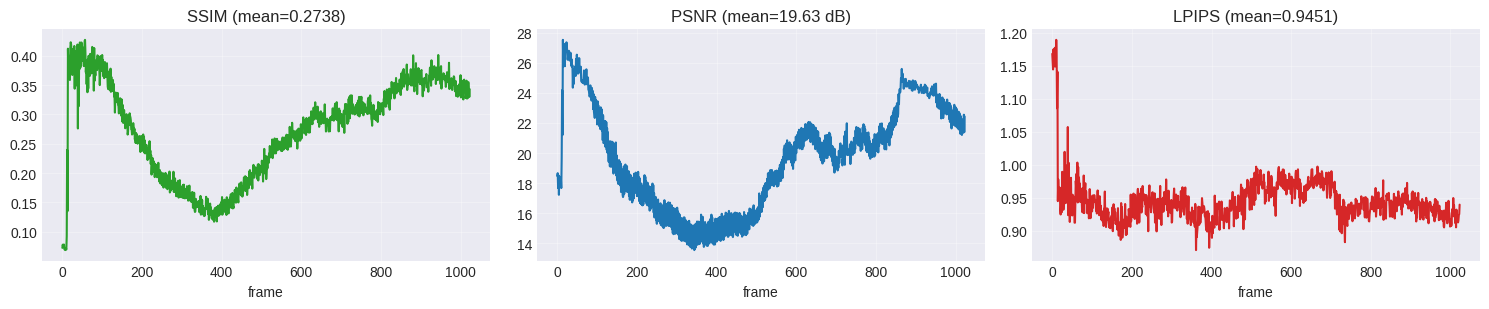

In [14]:
from skimage.metrics import structural_similarity as sk_ssim
try:
    from skimage.metrics import peak_signal_noise_ratio as sk_psnr
except Exception:
    sk_psnr = None

def _psnr_np(x, y, data_range):
    mse = np.mean((x.astype(np.float64) - y.astype(np.float64)) ** 2)
    return float('inf') if mse == 0 else float(20 * np.log10(data_range) - 10 * np.log10(mse))

T_, H_, W_ = flux_vol_true.shape
ssim_pf = np.zeros(T_); psnr_pf = np.zeros(T_)
for t in range(T_):
    gt, es = flux_vol_true[t], flux_est_vol[t]
    scale = max(gt.max(), 1e-8)
    gt_n = np.clip(gt / scale, 0.0, 1.0).astype(np.float32)
    es_n = np.clip(es / scale, 0.0, 1.0).astype(np.float32)
    ssim_pf[t] = sk_ssim(gt_n, es_n, data_range=1.0)
    psnr_pf[t] = sk_psnr(gt_n, es_n, data_range=1.0) if sk_psnr is not None else _psnr_np(gt_n, es_n, 1.0)

print(f"SSIM mean={ssim_pf.mean():.4f}  std={ssim_pf.std():.4f}  range=[{ssim_pf.min():.4f}, {ssim_pf.max():.4f}]")
print(f"PSNR mean={psnr_pf.mean():.2f} dB  std={psnr_pf.std():.2f}  range=[{psnr_pf.min():.2f}, {psnr_pf.max():.2f}]")

lpips_pf = None
try:
    import lpips as _lpips_mod
    if "_lpips_net" not in globals():
        _lpips_net = _lpips_mod.LPIPS(net="alex").to(device).eval()
        globals()["_lpips_net"] = _lpips_net
    lpips_pf = np.zeros(T_); LPIPS_BATCH = 32
    with torch.no_grad():
        for start in range(0, T_, LPIPS_BATCH):
            end = min(start + LPIPS_BATCH, T_)
            gt_chunk, es_chunk = flux_vol_true[start:end], flux_est_vol[start:end]
            scale = np.maximum(gt_chunk.reshape(end - start, -1).max(axis=1), 1e-8)[:, None, None]
            gt_n = np.clip(gt_chunk / scale, 0.0, 1.0).astype(np.float32)
            es_n = np.clip(es_chunk / scale, 0.0, 1.0).astype(np.float32)
            gt_t = torch.from_numpy(gt_n).to(device).unsqueeze(1).repeat(1, 3, 1, 1) * 2 - 1
            es_t = torch.from_numpy(es_n).to(device).unsqueeze(1).repeat(1, 3, 1, 1) * 2 - 1
            lpips_pf[start:end] = _lpips_net(gt_t, es_t).view(-1).cpu().numpy()
    print(f"LPIPS mean={lpips_pf.mean():.4f}  std={lpips_pf.std():.4f}  range=[{lpips_pf.min():.4f}, {lpips_pf.max():.4f}]")
except ImportError:
    print("LPIPS skipped: pip install lpips to enable.")

ncols = 3 if lpips_pf is not None else 2
fig, axes = plt.subplots(1, ncols, figsize=(5 * ncols, 3.2))
axes[0].plot(ssim_pf, color="#2ca02c"); axes[0].set_title(f"SSIM (mean={ssim_pf.mean():.4f})")
axes[0].set_xlabel("frame"); axes[0].grid(alpha=0.3)
axes[1].plot(psnr_pf, color="#1f77b4"); axes[1].set_title(f"PSNR (mean={psnr_pf.mean():.2f} dB)")
axes[1].set_xlabel("frame"); axes[1].grid(alpha=0.3)
if lpips_pf is not None:
    axes[2].plot(lpips_pf, color="#d62728"); axes[2].set_title(f"LPIPS (mean={lpips_pf.mean():.4f})")
    axes[2].set_xlabel("frame"); axes[2].grid(alpha=0.3)
plt.tight_layout(); plt.show()

In [15]:
# save the flux_est_vol as a playable mp4 (cv2)
import cv2
import numpy as np

prior_type = ("Temporal+Spatial" if TEMPORAL_FIRST else "Spatial+Temporal") + "_sigma=" + ("inf" if SWITCH_SIGMA == float('inf') else str(SWITCH_SIGMA))
if (not TEMPORAL_FIRST and SWITCH_SIGMA == float('inf')) or (TEMPORAL_FIRST and SWITCH_SIGMA == 0.0):
    prior_type = "Temporal" 
elif (TEMPORAL_FIRST and SWITCH_SIGMA == float('inf')) or (not TEMPORAL_FIRST and SWITCH_SIGMA == 0.0):
    prior_type = "Spatial"

out_path = "/u/scratch1/tan583/improved-diffusion-main/vid26_DAPS_" + prior_type + "_ppp=" + str(TARGET_PPP) + "_" + str(VOL_H) + "x" + str(VOL_W) + ".mp4"
fps = 30.0

# flux_est_vol is assumed shape [T, H, W]
T, H, W = flux_est_vol.shape

# Normalize to uint8 (0..255). If you already have uint8 frames, this keeps them unchanged.
vol = flux_est_vol
if vol.dtype != np.uint8:
    vmin = float(np.nanmin(vol))
    vmax = float(np.nanmax(vol))
    if not np.isfinite(vmin) or not np.isfinite(vmax) or vmax <= vmin:
        raise ValueError(f"Bad value range for video scaling: vmin={vmin}, vmax={vmax}")
    vol_u8 = np.clip((vol - vmin) * (255.0 / (vmax - vmin)), 0, 255).astype(np.uint8)
else:
    vol_u8 = vol

fourcc = cv2.VideoWriter_fourcc(*"mp4v")
writer = cv2.VideoWriter(out_path, fourcc, fps, (W, H), isColor=False)
if not writer.isOpened():
    raise RuntimeError(
        f"cv2.VideoWriter failed to open: {out_path}. "
        "Try fourcc='avc1' (H.264) if your OpenCV supports it, or write .avi with 'XVID'."
    )

for t in range(T):
    frame = np.ascontiguousarray(vol_u8[t])  # must be HxW uint8
    writer.write(frame)

writer.release()
print(f"Wrote {T} frames to {out_path} at {fps} fps, size={W}x{H}")

Wrote 1024 frames to /u/scratch1/tan583/improved-diffusion-main/vid26_DAPS_Spatial_ppp=0.01_256x256.mp4 at 30.0 fps, size=256x256
